<a href="https://colab.research.google.com/github/djdunc/hercules/blob/main/data/PatientsDayBarChart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

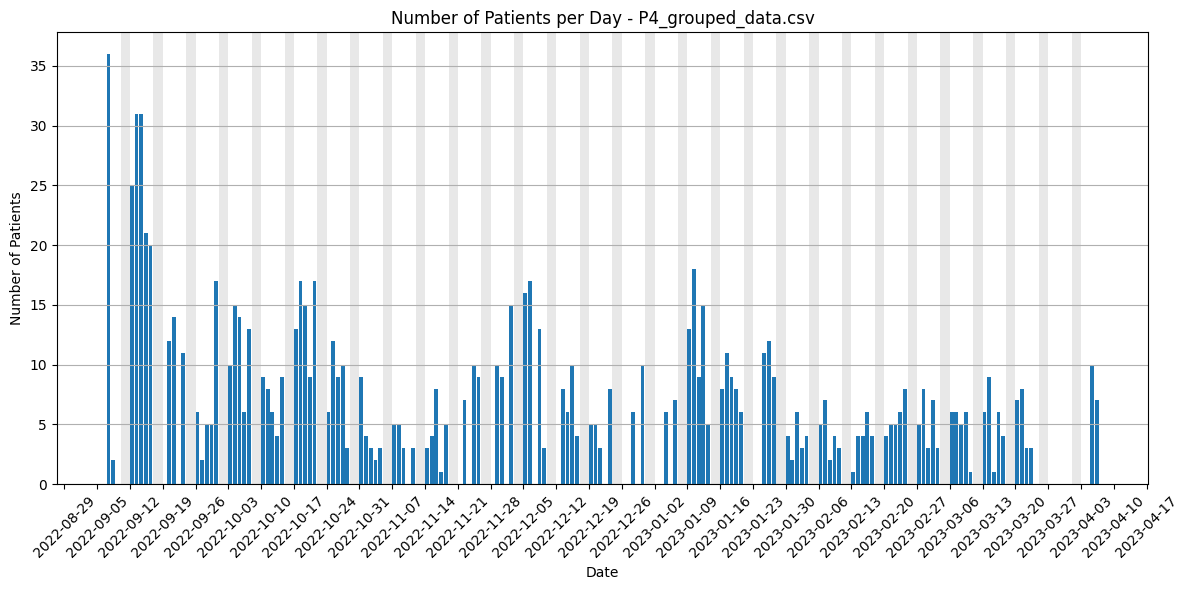

<Figure size 640x480 with 0 Axes>

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# If you are reading from a file, use the following instead of csv_data
file_path = 'P4_grouped_data.csv'
df = pd.read_csv(file_path)

# Convert 'starttime' to datetime objects
df['starttime'] = pd.to_datetime(df['starttime'])

# Extract the date from 'starttime'
df['date'] = df['starttime'].dt.date

# Group by date and count the number of rows
daily_counts = df.groupby('date').size()

# Get the full range of dates
start_date = df['date'].min()
end_date = df['date'].max()
date_range = pd.date_range(start=start_date, end=end_date, freq='D').date

# Reindex the daily counts to include all dates
daily_counts = daily_counts.reindex(date_range, fill_value=0)

# Plot the daily counts as a bar chart
plt.figure(figsize=(12, 6))
plt.bar(daily_counts.index, daily_counts.values, align='edge')
plt.title('Number of Patients per Day - ' + file_path)
plt.xlabel('Date')
plt.ylabel('Number of Patients')

# Highlight weekends
ax = plt.gca()
for date in daily_counts.index:
    if date.weekday() >= 5:  # 5=Saturday, 6=Sunday
        ax.axvspan(date, date + pd.Timedelta(days=1), facecolor='lightgray', alpha=0.5)

# Format x-axis to show every 7th date (or adjust as needed)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))  # Show every Thursday
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Date format
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

base_name = os.path.splitext(os.path.basename(file_path))[0]
save_filename = f"{base_name}-bar-chart.png"

# Save the plot as an image
plt.savefig(save_filename)
plt.show()